# Random Forest
In this notebook, we will utilize the RandomForest from sci-kit learn, and will use the builtin metrics to create and compare our model quickly and easily. We will evaluate performance based on the classification of the diabetes.csv dataset, which contains the outcome(positive or negative diagnoses for diabetes) based on certain features.

The project will follow three phases:
1. Data Preprocessing
2. Model Initialization and Training
3. Model Evaluation

## Data Preprocessing
In this phase, we will process the data, in order to make it usable for our purposes.
This phase contains the following sections
1. Import Modules
2. Read Data
3. Scale Data
4. Split Data

### Import Modules

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Read Data
We read the csv file of the data

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Scale Data
Here, we scale the data so that every feature is a value between 0 and 1.
We need to do this, so that values with large magnitude don't unduly influence the model.

In [3]:
scaler = StandardScaler()
features_to_scale = ['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,1
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,1
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,1


### Split Data
Now, we split the data into X_train, y_train, X_test, and y_test sets.
- X sets contain the features that will be input to the models.
- y sets contain the expected output outcomes from the model. 
- train sets will be used to train the data.
- test sets will be used to evaluate the data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], random_state=13)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(576, 8)
(192, 8)
(576,)
(192,)


## Model Initialization and Training
Here, we initialize the Random Forest Classifier using the sci-kit learn library.

In [5]:
forest = RandomForestClassifier(max_depth = 5, random_state=13)
forest = forest.fit(X_train, y_train)

## Model Evaluation
- Confusion Matrix
- F1 score
- F1 change with max depth and number of estimators

### Confusion Matrix
The confusion matrix below shows how our model performs on test values that it hasn't seen. One interesting exercise is to change the max depth, and see how the confusion matrix changes.

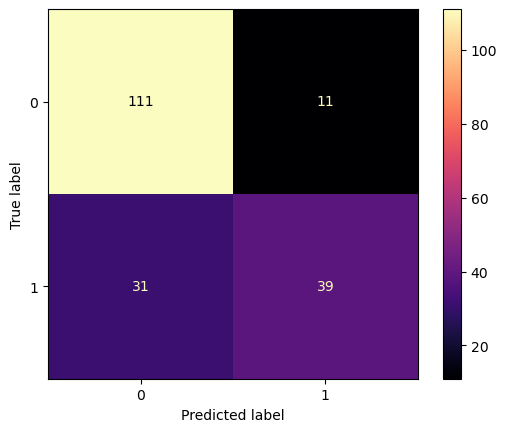

In [6]:
y_pred = forest.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap = 'magma')
plt.show()

### F1 score
With the max depth specified, we get the following F1 score. 

In [7]:
from sklearn.metrics import f1_score
print("The F1 score with weighted average is: " + str(f1_score(y_test, y_pred, average='weighted')) )

The F1 score with weighted average is: 0.7713068181818182


### F1 change with max depth and number of estimators
As shown in the 3D plot, the F1 score plateaus as max_depth and n_estimators increase. This happens because:

__Model Complexity Saturation:__ After a certain depth, trees fully capture the useful patterns, and extra depth doesn’t add predictive power.

__Stable Ensemble Predictions:__ Adding more trees initially reduces variance, but eventually the forest’s predictions stabilize, and extra trees don’t improve performance.

__Overfitting Resistance:__ Although very deep trees can memorize noise, random forests average over many trees, limiting overfitting’s impact on the overall F1 score.

This convergence shows the model has reached optimal complexity for the dataset.

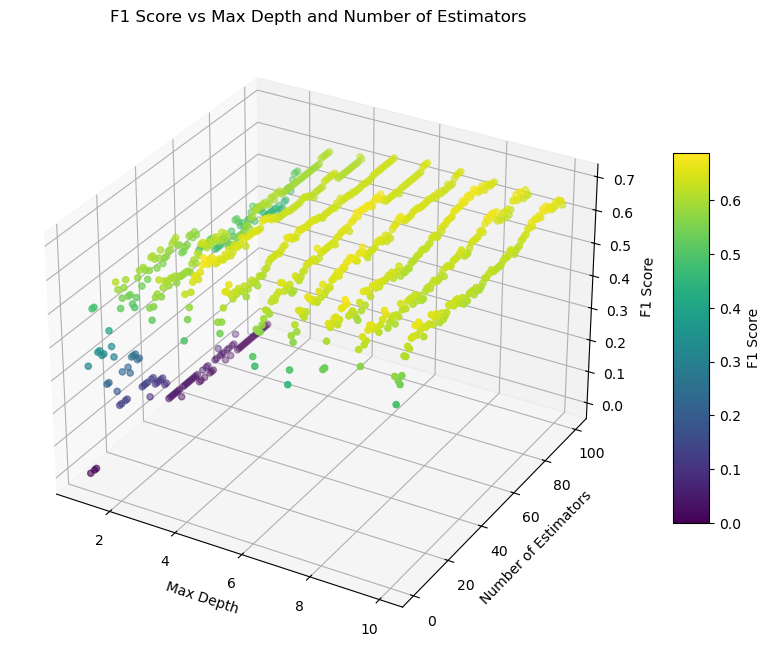

In [8]:
# Define ranges for both hyperparameters
max_depths = range(1, 11)         # max_depth values from 1 to 10 (adjust as needed)
n_estimators = range(1, 101)      # n_estimators values from 1 to 100

# Create lists to store the combinations and results
depth_list = []
estimators_list = []
f1_scores = []

# Iterate over both hyperparameters
for depth in max_depths:
    for n_est in n_estimators:
        clf = RandomForestClassifier(max_depth=depth, n_estimators=n_est, random_state=13)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        # Store the results
        depth_list.append(depth)
        estimators_list.append(n_est)
        f1_scores.append(f1)

# Convert lists to numpy arrays for plotting
depth_array = np.array(depth_list)
estimators_array = np.array(estimators_list)
f1_array = np.array(f1_scores)

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    depth_array, estimators_array, f1_array,
    c=f1_array, cmap='viridis', marker='o'
)

ax.set_title("F1 Score vs Max Depth and Number of Estimators")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Number of Estimators")
ax.set_zlabel("F1 Score")

# Add color bar to show F1 score intensity
fig.colorbar(scatter, ax=ax, shrink=0.6, aspect=10, label='F1 Score')

plt.show()